# 🧪 Computational Experiments: Validation of the Galois-Invariant Side-Channel Attack

**Reference Manuscript:** *Galois Invariants in Cyclotomic Lattice Enumeration: A GPU-Accelerated Meet-in-the-Middle Attack on Ring-LWE under Modular Filtration*

**Author:** José Ignacio Peinador Sala (Independent Researcher, Valladolid, Spain)[ORCID](https://orcid.org/0009-0008-1822-3452)

**Reproducibility DOI:** [10.5281/zenodo.19920082](https://doi.org/10.5281/zenodo.19920082)

---

## Overview

This notebook contains the three computational experiments that empirically validate the theoretical framework of the manuscript. Each experiment is designed to test a specific theorem or corollary, with explicit controls for reproducibility (fixed seeds, deterministic weight generation, and transparent target definition).

The experiments are organized in order of increasing complexity and decreasing dimension, allowing a progressive validation of the core claims:

| Experiment | Dimension | Objective | Key Result |
|---|---|---|---|
| **I** | $d = 32$ | Validate the Oracle Independence Law with **real prime ideal projections** | $9{,}026$ survivors vs. $9{,}083$ predicted ($0.63\%$ error) |
| **II** | $d = 36$ | Stress-test the Meet-in-the-Middle engine and verify the **regime of validity** of the equidis-tribution hypothesis | $10$ survivors at $Q/|S| \approx 0.1$; $1{,}048$ at $Q/|S| \approx 0.001$ |
| **III** | $d \in \{12, 15, 18, 21, 24\}$ | Characterize the **anisotropy of the density of states** under modular filtration | Multifractal scaling with $D_2^{(K)} < 1$ |

---

## Experiment I — Nodal Pruning and Statistical Validation ($d = 32$)

**Objective.** Validate the Oracle Independence Law (Theorem 4.1 of the manuscript) in the cyclotomic extension $\mathbb{Q}(\zeta_{64})$, using **real prime ideal projections** on the ring $R = \mathbb{Z}[x]/(x^{32}+1)$.

**Configuration.** Three orthogonal prime ideals with distinct inertia characteristics:
- $\mathfrak{p}_1$: $p_1 = 127$, $f_1 = 2$, $q_1 = 127^2 = 16{,}129$, $\omega_1 = 3$
- $\mathfrak{p}_2$: $p_2 = 65{,}537$, $f_2 = 1$, $q_2 = 65{,}537$, $\omega_2 = 5$
- $\mathfrak{p}_3$: $p_3 = 193$, $f_3 = 1$, $q_3 = 193$, $\omega_3 = 125$

The combined norm is $Q = q_1 \cdot q_2 \cdot q_3 \approx 2.04 \times 10^{11}$.

**Method.** A Meet-in-the-Middle engine splits the 32-dimensional ternary search space into two halves of dimension 16. The forward kernel projects the first half onto the three ideals; the backward kernel computes the required projection for the second half and searches it in the sorted forward table. The secret is sampled randomly with a fixed seed ($123{,}456{,}789$) and explicitly verified to be consistent with the target.

**Expected Result.** The Oracle Independence Law predicts $\mathbb{E}[|\Omega_{\text{conf}}|] = 3^{32}/Q \approx 9{,}083$ survivors. Empirically, we observe $9{,}026$ survivors, giving an error of $0.63\%$ and a normalized deviation of $0.60\sigma$ (Poisson), confirming the validity of the law in this regime.

**Manuscript Reference.** Section 6.3, Table 6.1.

---

## Experiment II — Extreme Stress Test and Regime Analysis ($d = 36$)

**Objective.** Stress-test the Meet-in-the-Middle engine at the physical limit of the NVIDIA Tesla T4 architecture, and verify the **regime of validity** of the equidis-tribution hypothesis (Hypothesis 2.1 of the manuscript).

**Configuration.** The cyclotomic extension $\mathbb{Q}(\zeta_{72})$ of dimension $d = 36$ yields a search space of $|S| = 3^{36} \approx 1.50 \times 10^{17}$ ternary vectors. The forward sub-table stores $3^{18} = 387{,}420{,}489$ keys (2.88 GiB VRAM). Two values of $Q$ are tested:
- **Configuration A** (canonical regime): $Q = 1.5 \times 10^{16}$, $Q/|S| \approx 0.1$.
- **Configuration B** (transition regime): $Q = 1.5 \times 10^{14}$, $Q/|S| \approx 0.001$.

**Method.** The projection is modeled as a linear combination $\pi(s) = \sum_j s_j \cdot w_j \bmod Q$ with pseudo-random weights generated by a fixed-seed xorshift PRNG. The target is computed as the projection of a known secret, ensuring reachability. Explicit synchronization between phases (forward, sort, backward) guarantees accurate timing.

**Expected Result.** In Configuration A, the law predicts $10.0063$ survivors; we observe $10$ (ratio $0.9994$). In Configuration B, the law predicts $1{,}000.63$ survivors; we observe $1{,}048$ (ratio $1.0473$, consistent with Poisson variance). Both results fall within the $95\%$ Poisson confidence interval, confirming the validity of the equidis-tribution hypothesis in the range $Q/|S| \in [10^{-3}, 10^{-1}]$.

**Manuscript Reference.** Section 6.4, Table 6.2 and Table 6.3.

---

## Experiment III — Anisotropy of the Density of States ($d \in \{12, 15, 18, 21, 24\}$)

**Objective.** Empirically characterize the **anisotropy of the density of states** induced by modular filtration, validating the theoretical prediction of Theorem 4.4 of the manuscript.

**Configuration.** For each dimension $d$, the experiment evaluates the full ternary search space $\{-1, 0, 1\}^d$ under multiple modular projections. Two or three prime ideals are used per dimension, with combined norms $Q \approx 1.68 \times 10^7$ (for $d \le 18$) or $Q \approx 3.25 \times 10^9$ (for $d \ge 21$).

**Method.** The experimental scan proceeds dimension by dimension, accumulating an adaptive ensemble of realizations with uniformly sampled targets. The key observables are:
- The mean number of survivors $\langle |\Omega_{\text{conf}}| \rangle$.
- The Inverse Participation Ratio (IPR) $\langle Y_2 \rangle$, measuring the concentration of the density of states.
- The effective fractal dimension $D_2^{(K)} = \ln \langle |\Omega_{\text{conf}}| \rangle / (d \ln 3)$, compared against the analytical prediction $D_2^{\text{analytic}} = 1 - \ln Q / (d \ln 3)$.

**Expected Result.** Across all dimensions, the empirical IPR $\langle Y_2 \rangle$ diverges by more than 10 orders of magnitude from the uniform-ensemble bound $Y_2^{\text{unif}} = 1/3^d$. The empirical fractal dimension $D_2^{\text{emp}}$ coincides with the analytical prediction $D_2^{\text{analytic}}$ within a relative error below $1.3\%$, confirming the multifractal scaling predicted by Theorem 4.4.

**Manuscript Reference.** Section 6.5, Table 6.4 and Figure 1.

---

## Reproducibility Notes

All experiments use **fixed seeds** and **deterministic weight generation** to guarantee bit-for-bit reproducibility. The following controls are enforced:

- **Secret sampling**: uniformly random with seed $123{,}456{,}789$ (Experiment I) or $987{,}654{,}321$ (Experiments II and III).
- **Weight generation**: xorshift-based PRNG with fixed seed.
- **Target definition**: computed as the projection of a known secret, ensuring reachability.
- **Synchronization**: explicit `cudaDeviceSynchronize()` between phases for accurate timing.
- **Environment reporting**: GPU model, CUDA runtime, compiler version, and global seed are printed at the start of each experiment.

The complete source code, compilation scripts, and benchmark logs are available in the GitHub repository ([https://github.com/NachoPeinador/Galois-Lattice-Pruning](https://github.com/NachoPeinador/Galois-Lattice-Pruning)) and archived on Zenodo with a permanent DOI ([10.5281/zenodo.19920082](https://doi.org/10.5281/zenodo.19920082)).

**Expected total runtime**: approximately 15 minutes on an NVIDIA Tesla T4 (SM 7.5), with the breakdown dominated by Experiment II ($\sim 7$ seconds per configuration) and Experiment III ($\sim 3$ minutes for all dimensions).

---

## Epistemic Boundaries

For maximum scientific rigor, we explicitly declare the following boundaries of the computational validation:

**What the experiments validate:**
- The **Oracle Independence Law** (Theorem 4.1) in multiple regimes of $Q/|S|$.
- The **anisotropy of the density of states** (Theorem 4.4) across five dimensions.
- The **engineering performance** of the Meet-in-the-Middle engine at the physical limit of the Tesla T4.

**What the experiments do not validate:**
- The **physical leakage mechanism** from a real NTT implementation. The experiments use an abstract model of modular oracle, justified by the experimental literature on modular leakage in NTT.
- The **scalability to full ML-KEM dimension** ($d = 256$). The extrapolation to $d = 256$ is analytical (Section 5 of the manuscript) and certified in Lean 4, not empirically measured.
- The **multifractal conjecture** (Conjecture 4.1). The experiments provide empirical evidence for the conjecture but do not constitute a proof.

These boundaries ensure that the computational validation is interpreted within its proper scope and does not overstate the empirical evidence.

In [1]:
# ==============================================================================
# 🧪 Computational Experiments: Validation of the Galois-Invariant Side-Channel Attack
#
# Reference Manuscript: Galois Invariants in Cyclotomic Lattice Enumeration:
# A GPU-Accelerated Meet-in-the-Middle Attack on Ring-LWE under Modular Filtration
#
# Author: José Ignacio Peinador Sala (Independent Researcher, Valladolid, Spain)
# ORCID: https://orcid.org/0009-0008-1822-3452
# Reproducibility DOI: https://doi.org/10.5281/zenodo.19920082
# ==============================================================================

import os
import subprocess
import sys

# ------------------------------------------------------------------------------
# High-Performance CUDA Source Code: Experiment I (d=32, Q(zeta_64))
# ------------------------------------------------------------------------------
cuda_code = r"""
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <cmath>
#include <cuda_runtime.h>
#include <thrust/sort.h>
#include <thrust/device_ptr.h>

// Macro for GPU API error checking with real-time file and line reporting
#define CHECK_CUDA(call) { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA Error: " << cudaGetErrorString(err) << " at line " << __LINE__ << std::endl; \
        exit(1); \
    } \
}

// Cyclotomic Extension Parameters: Q(zeta_64), Dimension d = 32
const int D = 32;
const int D_HALF = 16;
const unsigned long long N_HALF = 43046721ULL; // 3^16 state subspace size

// Ideal Norms in Constant GPU Memory: q_i = p_i^{f_i}
__constant__ unsigned long long Q1 = 16129ULL; // p1 = 127 (inertia degree f1 = 2)
__constant__ unsigned long long Q2 = 65537ULL; // p2 = 65537 (inertia degree f2 = 1)
__constant__ unsigned long long Q3 = 193ULL;   // p3 = 193 (inertia degree f3 = 1)

// Cyclotomic Power Base Pre-computations (evaluations on finite field roots)
__constant__ unsigned long long W1[32];
__constant__ unsigned long long W2[32];
__constant__ unsigned long long W3[32];

// Target Modular Residuals (Target Secret Projections)
__constant__ unsigned long long TAU1;
__constant__ unsigned long long TAU2;
__constant__ unsigned long long TAU3;

/**
 * @brief Packs three modular residues into a single 64-bit integer key.
 * Uses bit-shifting without overlap to maximize VRAM memory alignment and sorting speed.
 */
__device__ __host__ inline uint64_t pack_key(uint64_t r1, uint64_t r2, uint64_t r3) {
    return (r1 & 0x7FFF) | ((r2 & 0x3FFFF) << 15) | ((r3 & 0xFF) << 33);
}

/**
 * @brief Binary search on GPU VRAM to count exact target key collisions in the sorted Forward table.
 */
__device__ unsigned long long count_matches_gpu(const uint64_t* keys, unsigned long long size, uint64_t target) {
    long long l = 0, r = size - 1;
    long long first = -1;

    // Find lower bound
    while (l <= r) {
        long long mid = l + (r - l) / 2;
        if (keys[mid] == target) { first = mid; r = mid - 1; }
        else if (keys[mid] < target) { l = mid + 1; }
        else { r = mid - 1; }
    }
    if (first == -1) return 0;

    // Find upper bound
    l = first; r = size - 1; long long last = first;
    while (l <= r) {
        long long mid = l + (r - l) / 2;
        if (keys[mid] == target) { last = mid; l = mid + 1; }
        else if (keys[mid] < target) { l = mid + 1; }
        else { r = mid - 1; }
    }
    return (unsigned long long)(last - first + 1);
}

/**
 * @brief Forward Stage Kernel: Generates 3^16 packed residue keys from base-3 decoded ternary candidates.
 */
__global__ void kernel_forward_generate(uint64_t* d_forward_keys) {
    unsigned long long idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= N_HALF) return;

    // Base-10 thread ID to Base-3 ternary vector decoding: {-1, 0, 1}^16
    unsigned long long tmp = idx;
    int s[16];
    #pragma unroll
    for (int j = 0; j < 16; ++j) {
        s[j] = (int)(tmp % 3) - 1;
        tmp /= 3;
    }

    // Evaluate modular projections over the first half of the polynomial
    long long r1 = 0, r2 = 0, r3 = 0;
    #pragma unroll
    for (int j = 0; j < 16; ++j) {
        r1 += (long long)s[j] * W1[j];
        r2 += (long long)s[j] * W2[j];
        r3 += (long long)s[j] * W3[j];
    }

    uint64_t mod_r1 = (uint64_t)((r1 % (long long)Q1 + Q1) % Q1);
    uint64_t mod_r2 = (uint64_t)((r2 % (long long)Q2 + Q2) % Q2);
    uint64_t mod_r3 = (uint64_t)((r3 % (long long)Q3 + Q3) % Q3);

    d_forward_keys[idx] = pack_key(mod_r1, mod_r2, mod_r3);
}

/**
 * @brief Backward Interception Kernel: Evaluates required complement residues and performs parallel VRAM search.
 */
__global__ void kernel_backward_search(const uint64_t* d_forward_keys, unsigned long long* d_survivors) {
    unsigned long long idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= N_HALF) return;

    // Base-10 thread ID to Base-3 ternary vector decoding: {-1, 0, 1}^16
    unsigned long long tmp = idx;
    int s[16];
    #pragma unroll
    for (int j = 0; j < 16; ++j) {
        s[j] = (int)(tmp % 3) - 1;
        tmp /= 3;
    }

    // Evaluate modular projections over the second half of the polynomial
    long long r1 = 0, r2 = 0, r3 = 0;
    #pragma unroll
    for (int j = 0; j < 16; ++j) {
        r1 += (long long)s[j] * W1[j + 16];
        r2 += (long long)s[j] * W2[j + 16];
        r3 += (long long)s[j] * W3[j + 16];
    }

    // Calculate complement target residues
    uint64_t req1 = (uint64_t)(((long long)TAU1 - r1) % (long long)Q1 + Q1) % Q1;
    uint64_t req2 = (uint64_t)(((long long)TAU2 - r2) % (long long)Q2 + Q2) % Q2;
    uint64_t req3 = (uint64_t)(((long long)TAU3 - r3) % (long long)Q3 + Q3) % Q3;

    uint64_t target_key = pack_key(req1, req2, req3);
    unsigned long long matches = count_matches_gpu(d_forward_keys, N_HALF, target_key);

    if (matches > 0) {
        atomicAdd(d_survivors, matches);
    }
}

int main() {
    std::cout << "=======================================================================\n";
    std::cout << " CUDA MITM: ORACLE INDEPENDENCE LAW IN CYCLOTOMIC RINGS (d=32)\n";
    std::cout << "=======================================================================\n";

    // Initialization: Cyclotomic Power Base Pre-computations
    std::vector<uint64_t> h_w1(32), h_w2(32), h_w3(32);
    std::vector<int> secret(32);

    uint64_t base1 = 3, base2 = 5, base3 = 125;
    uint64_t w1 = 1, w2 = 1, w3 = 1;

    for(int i = 0; i < 32; ++i) {
        // Deterministic PRNG seed generation for secret sampling (prevents degenerate patterns)
        uint64_t tmp_seed = 123456789ULL + i;
        tmp_seed ^= tmp_seed << 21; tmp_seed ^= tmp_seed >> 35; tmp_seed ^= tmp_seed << 4;
        secret[i] = (int)(tmp_seed % 3) - 1;

        h_w1[i] = w1; w1 = (w1 * base1) % 16129ULL;
        h_w2[i] = w2; w2 = (w2 * base2) % 65537ULL;
        h_w3[i] = w3; w3 = (w3 * base3) % 193ULL;
    }

    // Verification of Multiplicative Order for Finite Field Roots
    auto verify_root_order = [](uint64_t base, uint64_t mod, int min_order, const char* name) {
        uint64_t val = 1;
        for (int k = 1; k <= min_order; ++k) {
            val = (val * base) % mod;
            if (val == 1 && k < min_order) {
                std::cerr << "WARNING: " << name << " has order " << k
                          << " < " << min_order << std::endl;
                return false;
            }
        }
        return true;
    };

    verify_root_order(base1, 16129, 32, "omega_1 (base=3, mod=16129)");
    verify_root_order(base2, 65537, 32, "omega_2 (base=5, mod=65537)");
    verify_root_order(base3, 193, 32, "omega_3 (base=125, mod=193)");

    // Compute Secret Modular Projections (Target Residuums)
    long long h_tau1 = 0, h_tau2 = 0, h_tau3 = 0;
    for(int i = 0; i < 32; ++i) {
        h_tau1 += (long long)secret[i] * (long long)h_w1[i];
        h_tau2 += (long long)secret[i] * (long long)h_w2[i];
        h_tau3 += (long long)secret[i] * (long long)h_w3[i];
    }

    uint64_t tau1_final = (uint64_t)((h_tau1 % 16129LL + 16129LL) % 16129LL);
    uint64_t tau2_final = (uint64_t)((h_tau2 % 65537LL + 65537LL) % 65537LL);
    uint64_t tau3_final = (uint64_t)((h_tau3 % 193LL + 193LL) % 193LL);

    // Copy Constant Parameters and Projections to GPU Constant Memory
    CHECK_CUDA(cudaMemcpyToSymbol(W1, h_w1.data(), 32 * sizeof(uint64_t)));
    CHECK_CUDA(cudaMemcpyToSymbol(W2, h_w2.data(), 32 * sizeof(uint64_t)));
    CHECK_CUDA(cudaMemcpyToSymbol(W3, h_w3.data(), 32 * sizeof(uint64_t)));
    CHECK_CUDA(cudaMemcpyToSymbol(TAU1, &tau1_final, sizeof(uint64_t)));
    CHECK_CUDA(cudaMemcpyToSymbol(TAU2, &tau2_final, sizeof(uint64_t)));
    CHECK_CUDA(cudaMemcpyToSymbol(TAU3, &tau3_final, sizeof(uint64_t)));

    // Allocate VRAM Arrays
    uint64_t* d_forward_keys;
    unsigned long long* d_survivors;
    CHECK_CUDA(cudaMalloc(&d_forward_keys, N_HALF * sizeof(uint64_t)));
    CHECK_CUDA(cudaMalloc(&d_survivors, sizeof(unsigned long long)));
    CHECK_CUDA(cudaMemset(d_survivors, 0, sizeof(unsigned long long)));

    // Create CUDA Timing Events
    cudaEvent_t start_fwd, stop_fwd, start_sort, stop_sort, start_bwd, stop_bwd;
    cudaEventCreate(&start_fwd); cudaEventCreate(&stop_fwd);
    cudaEventCreate(&start_sort); cudaEventCreate(&stop_sort);
    cudaEventCreate(&start_bwd); cudaEventCreate(&stop_bwd);

    int threads = 256;
    int blocks = (N_HALF + threads - 1) / threads;

    // Stage 1: Forward Table Generation
    cudaEventRecord(start_fwd);
    kernel_forward_generate<<<blocks, threads>>>(d_forward_keys);
    cudaEventRecord(stop_fwd);

    // Stage 2: Parallel VRAM Radix Sorting (NVIDIA Thrust)
    cudaEventRecord(start_sort);
    thrust::device_ptr<uint64_t> dev_ptr(d_forward_keys);
    thrust::sort(dev_ptr, dev_ptr + N_HALF);
    cudaEventRecord(stop_sort);

    // Stage 3: Backward Interception Search
    cudaEventRecord(start_bwd);
    kernel_backward_search<<<blocks, threads>>>(d_forward_keys, d_survivors);
    cudaEventRecord(stop_bwd);

    CHECK_CUDA(cudaDeviceSynchronize());

    float ms_fwd = 0, ms_sort = 0, ms_bwd = 0;
    cudaEventElapsedTime(&ms_fwd, start_fwd, stop_fwd);
    cudaEventElapsedTime(&ms_sort, start_sort, stop_sort);
    cudaEventElapsedTime(&ms_bwd, start_bwd, stop_bwd);

    unsigned long long h_survivors = 0;
    CHECK_CUDA(cudaMemcpy(&h_survivors, d_survivors, sizeof(unsigned long long), cudaMemcpyDeviceToHost));

    // Theoretical Evaluation: Oracle Independence Law Verification
    double prod_q = 16129.0 * 65537.0 * 193.0;
    double expected_survivors = 1853020188851841.0 / prod_q;
    double sigma_poisson = std::sqrt(expected_survivors);
    double pruning_rate = (1.0 - (double)h_survivors / 1853020188851841.0) * 100.0;
    double error_margin = std::abs((double)h_survivors - expected_survivors) / expected_survivors * 100.0;

    std::cout << "[HPC ATTACK METRICS]:\n";
    std::cout << " Total VRAM Execution Time : " << ms_fwd + ms_sort + ms_bwd << " ms\n";
    std::cout << " Effective Throughput      : " << (1.853020188851841e15 / ((ms_fwd + ms_sort + ms_bwd) / 1000.0)) / 1e15 << " Peta-Candidates / sec\n\n";

    std::cout << "[ANALYTICAL RIGOR: ORACLE INDEPENDENCE LAW]:\n";
    std::cout << " GPU Empirical Survivors    : " << h_survivors << " vectors\n";
    std::cout << " Theoretical Prediction     : " << std::fixed << std::setprecision(2) << expected_survivors << " vectors\n";
    std::cout << " Poisson Std. Deviation     : " << std::setprecision(2) << sigma_poisson << " vectors\n";
    std::cout << " Deviation Error Margin     : " << std::setprecision(2) << error_margin << " %\n";
    std::cout << " Effective Pruning Rate     : " << std::setprecision(8) << pruning_rate << " %\n\n";

    std::cout << " CONCLUSION: Empirical convergence validates the Oracle Independence Law\n";
    std::cout << " in the regime Q/|S| = " << std::setprecision(4) << (prod_q / 1853020188851841.0) << ".\n";

    cudaFree(d_forward_keys);
    cudaFree(d_survivors);
    return 0;
}
"""

# Path definitions
src_path = "/content/mitm_cyclotomic_q1.cu"
bin_path = "/content/mitm_cyclotomic_q1"

with open(src_path, "w") as f:
    f.write(cuda_code)

print("⚙️ Compiling Rigorous CUDA MitM Engine (Power Base)...")
res = subprocess.run(f"nvcc -O3 -arch=sm_75 {src_path} -o {bin_path}", shell=True, capture_output=True, text=True)

if res.returncode != 0:
    print("❌ Compilation Error:\n", res.stderr)
else:
    print("✅ Compilation Successful. Executing Q1 Demonstration...\n")
    proc = subprocess.Popen([bin_path], stdout=subprocess.PIPE, text=True)
    for line in proc.stdout:
        sys.stdout.write(line)
        sys.stdout.flush()
    proc.wait()

⚙️ Compiling Rigorous CUDA MitM Engine (Power Base)...
✅ Compilation Successful. Executing Q1 Demonstration...

 CUDA MITM: ORACLE INDEPENDENCE LAW IN CYCLOTOMIC RINGS (d=32)
[HPC ATTACK METRICS]:
 Total VRAM Execution Time : 298.271 ms
 Effective Throughput      : 6.21255 Peta-Candidates / sec

[ANALYTICAL RIGOR: ORACLE INDEPENDENCE LAW]:
 GPU Empirical Survivors    : 9026 vectors
 Theoretical Prediction     : 9082.99 vectors
 Poisson Std. Deviation     : 95.30 vectors
 Deviation Error Margin     : 0.63 %
 Effective Pruning Rate     : 100.00000000 %

 CONCLUSION: Empirical convergence validates the Oracle Independence Law
 in the regime Q/|S| = 0.0001.


In [2]:
# ==============================================================================
# 🧪 Computational Experiments: Validation of the Galois-Invariant Side-Channel Attack
#
# Reference Manuscript: Galois Invariants in Cyclotomic Lattice Enumeration:
# A GPU-Accelerated Meet-in-the-Middle Attack on Ring-LWE under Modular Filtration
#
# Author: José Ignacio Peinador Sala (Independent Researcher, Valladolid, Spain)
# ORCID: https://orcid.org/0009-0008-1822-3452
# Reproducibility DOI: https://doi.org/10.5281/zenodo.19920082
# ==============================================================================

import os
import subprocess
import sys

# =============================================================================
# EXTREME MITM ENGINE (d=36) — FINAL VERSION FOR Q1 JOURNAL SUBMISSION
# =============================================================================
# This module implements the extreme MitM experiment for dimension d=36,
# evaluating two distinct regimes of the oracle norm Q against the search
# space volume |S| = 3^36 to validate the Oracle Independence Law.
#
# Key Features:
# - Precise MitM decomposition using weight offset `d_weights + half_d` in backward search.
# - Target residuum computed from a known sampled secret (guaranteed reachability).
# - Explicit GPU synchronization events for microsecond-accurate timing.
# - Regime analysis across two configurations (Canonical Q ≈ 0.1|S| vs Transition Q ≈ 0.001|S|).
# =============================================================================

cuda_code = r"""
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>
#include <cuda_runtime.h>
#include <thrust/device_ptr.h>
#include <thrust/sort.h>

// Macro for GPU API error checking with real-time file and line reporting
#define CHECK_CUDA(call) { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA Error: " << cudaGetErrorString(err) << " at line " << __LINE__ << std::endl; \
        exit(1); \
    } \
}

/**
 * @brief Generates pseudo-random weights for the modular oracle projection on Host.
 */
void generate_oracle_weights(std::vector<uint64_t>& weights, int d, uint64_t Q) {
    uint64_t seed = 987654321ULL;
    for (int i = 0; i < d; ++i) {
        seed ^= seed << 21; seed ^= seed >> 35; seed ^= seed << 4;
        weights[i] = seed % Q;
    }
}

/**
 * @brief Evaluates the modular linear projection of a sub-vector on GPU Device.
 */
__device__ uint64_t project_residue(uint64_t vector_id, int dim,
                                     const uint64_t* weights, uint64_t Q) {
    long long sum = 0;
    uint64_t temp = vector_id;
    for (int i = 0; i < dim; ++i) {
        long long coef = (long long)(temp % 3) - 1; // Map base-3 digit to {-1, 0, 1}
        sum = (sum + coef * (long long)weights[i]) % (long long)Q;
        temp /= 3;
    }
    if (sum < 0) sum += (long long)Q;
    return static_cast<uint64_t>(sum);
}

/**
 * @brief Evaluates the modular linear projection of a sub-vector on Host CPU.
 */
uint64_t project_residue_host(uint64_t vector_id, int dim,
                               const uint64_t* weights, uint64_t Q) {
    long long sum = 0;
    uint64_t temp = vector_id;
    for (int i = 0; i < dim; ++i) {
        long long coef = (long long)(temp % 3) - 1; // Map base-3 digit to {-1, 0, 1}
        sum = (sum + coef * (long long)weights[i]) % (long long)Q;
        temp /= 3;
    }
    if (sum < 0) sum += (long long)Q;
    return static_cast<uint64_t>(sum);
}

/**
 * @brief Forward Stage Kernel: Computes partial modular projections for the first half of the secret.
 */
__global__ void forward_kernel(uint64_t total_states, int half_d,
                               const uint64_t* d_weights, uint64_t Q,
                               uint64_t* d_table) {
    uint64_t id = (uint64_t)blockIdx.x * blockDim.x + threadIdx.x;
    if (id < total_states) {
        d_table[id] = project_residue(id, half_d, d_weights, Q);
    }
}

/**
 * @brief Backward Stage Kernel: Computes target complement residues and performs parallel binary search.
 */
__global__ void backward_kernel(uint64_t total_states, int half_d,
                                const uint64_t* d_weights, uint64_t Q,
                                uint64_t target,
                                const uint64_t* __restrict__ d_table,
                                unsigned long long* d_survivors) {
    uint64_t id = (uint64_t)blockIdx.x * blockDim.x + threadIdx.x;
    if (id >= total_states) return;

    uint64_t my_residue = project_residue(id, half_d, d_weights, Q);
    uint64_t target_val = ((long long)target + (long long)Q - (long long)my_residue) % (long long)Q;

    // Binary search lower bound
    uint64_t left = 0;
    uint64_t right = total_states;
    while (left < right) {
        uint64_t mid = left + (right - left) / 2;
        if (d_table[mid] < target_val) left = mid + 1;
        else right = mid;
    }

    // Count collisions in the sorted Forward table
    if (left < total_states && d_table[left] == target_val) {
        unsigned long long collisions = 0;
        while (left + collisions < total_states && d_table[left + collisions] == target_val) {
            collisions++;
        }
        atomicAdd(d_survivors, collisions);
    }
}

struct Result {
    unsigned long long survivors;
    float time_forward_ms;
    float time_sort_ms;
    float time_backward_ms;
    bool secret_consistent;
};

/**
 * @brief Executes a complete MitM evaluation for a given oracle norm configuration Q.
 */
Result run_configuration(int d, int half_d, uint64_t total_states,
                         uint64_t Q, uint64_t secret_id) {
    Result res = {0, 0, 0, 0, false};

    std::vector<uint64_t> weights(d);
    generate_oracle_weights(weights, d, Q);

    uint64_t target = project_residue_host(secret_id, d, weights.data(), Q);

    uint64_t* d_weights;
    CHECK_CUDA(cudaMalloc(&d_weights, d * sizeof(uint64_t)));
    CHECK_CUDA(cudaMemcpy(d_weights, weights.data(), d * sizeof(uint64_t),
                          cudaMemcpyHostToDevice));

    uint64_t* d_table;
    CHECK_CUDA(cudaMalloc(&d_table, total_states * sizeof(uint64_t)));

    unsigned long long* d_survivors;
    CHECK_CUDA(cudaMalloc(&d_survivors, sizeof(unsigned long long)));
    CHECK_CUDA(cudaMemset(d_survivors, 0, sizeof(unsigned long long)));

    int blockSize = 256;
    int numBlocks = (int)((total_states + blockSize - 1) / blockSize);

    cudaEvent_t t0, t1, t2, t3, t4, t5;
    cudaEventCreate(&t0); cudaEventCreate(&t1); cudaEventCreate(&t2);
    cudaEventCreate(&t3); cudaEventCreate(&t4); cudaEventCreate(&t5);

    // Forward Generation Stage
    cudaEventRecord(t0);
    forward_kernel<<<numBlocks, blockSize>>>(total_states, half_d, d_weights, Q, d_table);
    cudaEventRecord(t1);
    CHECK_CUDA(cudaDeviceSynchronize());

    // Parallel VRAM Radix Sorting Stage (NVIDIA Thrust)
    cudaEventRecord(t2);
    thrust::device_ptr<uint64_t> thrust_ptr(d_table);
    thrust::sort(thrust_ptr, thrust_ptr + total_states);
    cudaEventRecord(t3);
    CHECK_CUDA(cudaDeviceSynchronize());

    // Backward Interception Stage (Using second half of weights: d_weights + half_d)
    cudaEventRecord(t4);
    backward_kernel<<<numBlocks, blockSize>>>(total_states, half_d, d_weights + half_d, Q,
                                               target, d_table, d_survivors);
    cudaEventRecord(t5);
    CHECK_CUDA(cudaDeviceSynchronize());

    cudaEventElapsedTime(&res.time_forward_ms, t0, t1);
    cudaEventElapsedTime(&res.time_sort_ms, t2, t3);
    cudaEventElapsedTime(&res.time_backward_ms, t4, t5);

    CHECK_CUDA(cudaMemcpy(&res.survivors, d_survivors,
                          sizeof(unsigned long long), cudaMemcpyDeviceToHost));

    uint64_t target_check = project_residue_host(secret_id, d, weights.data(), Q);
    res.secret_consistent = (target_check == target);

    cudaFree(d_weights); cudaFree(d_table); cudaFree(d_survivors);
    return res;
}

int main() {
    int d = 36;
    int half_d = d / 2;
    uint64_t total_states = 387420489ULL; // 3^18 states per half
    uint64_t secret_id = 123456789ULL;

    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, 0);
    std::cout << "=================================================================\n";
    std::cout << " EXTREME CUDA MITM ENGINE (d=36) — ROBUST v3\n";
    std::cout << "=================================================================\n";
    std::cout << " Device       : " << prop.name << " (SM " << prop.major << "." << prop.minor << ")\n";
    std::cout << " CUDA Runtime : " << CUDART_VERSION << "\n";
    std::cout << " Compiler     : nvcc " << __VERSION__ << "\n";
    std::cout << " Seed         : 987654321ULL\n";
    std::cout << " Secret ID    : " << secret_id << "\n";
    std::cout << "-----------------------------------------------------------------\n";
    std::cout << " Dimension d  : " << d << "\n";
    std::cout << " Total states : 3^36 = 150094635296999121\n\n";

    uint64_t Q_A = 15000000000000000ULL;
    uint64_t Q_B = 150000000000000ULL;

    std::cout << "[Regime Analysis: Q vs |S|]\n";
    std::cout << " Config |        Q         | Q/|S|    | E[Omega]\n";
    std::cout << " -------|------------------|----------|----------\n";
    std::cout << " A      | " << Q_A << " | " << std::fixed << std::setprecision(4)
              << (double)Q_A / 150094635296999121.0 << "   | "
              << 150094635296999121.0 / (double)Q_A << "\n";
    std::cout << " B      | " << Q_B << " | " << std::fixed << std::setprecision(4)
              << (double)Q_B / 150094635296999121.0 << "   | "
              << 150094635296999121.0 / (double)Q_B << "\n\n";

    std::cout << "[Config A: Canonical Regime (Q ≈ 0.1|S|)]\n";
    Result resA = run_configuration(d, half_d, total_states, Q_A, secret_id);
    double theoryA = 150094635296999121.0 / (double)Q_A;
    std::cout << " Forward  : " << resA.time_forward_ms << " ms\n";
    std::cout << " Sort     : " << resA.time_sort_ms << " ms\n";
    std::cout << " Backward : " << resA.time_backward_ms << " ms\n";
    std::cout << " Total    : " << (resA.time_forward_ms + resA.time_sort_ms + resA.time_backward_ms) / 1000.0 << " s\n";
    std::cout << " Theoretical E[Omega] : " << std::setprecision(6) << theoryA << "\n";
    std::cout << " Empirical survivors  : " << resA.survivors << "\n";
    std::cout << " Ratio emp/theo       : " << std::setprecision(4)
              << (double)resA.survivors / theoryA << "\n";
    std::cout << " Secret consistent    : " << (resA.secret_consistent ? "YES" : "NO") << "\n\n";

    std::cout << "[Config B: Transition Regime (Q ≈ 0.001|S|)]\n";
    Result resB = run_configuration(d, half_d, total_states, Q_B, secret_id);
    double theoryB = 150094635296999121.0 / (double)Q_B;
    std::cout << " Forward  : " << resB.time_forward_ms << " ms\n";
    std::cout << " Sort     : " << resB.time_sort_ms << " ms\n";
    std::cout << " Backward : " << resB.time_backward_ms << " ms\n";
    std::cout << " Total    : " << (resB.time_forward_ms + resB.time_sort_ms + resB.time_backward_ms) / 1000.0 << " s\n";
    std::cout << " Theoretical E[Omega] : " << std::setprecision(6) << theoryB << "\n";
    std::cout << " Empirical survivors  : " << resB.survivors << "\n";
    std::cout << " Ratio emp/theo       : " << std::setprecision(4)
              << (double)resB.survivors / theoryB << "\n";
    std::cout << " Secret consistent    : " << (resB.secret_consistent ? "YES" : "NO") << "\n\n";

    std::cout << "=================================================================\n";
    return 0;
}
"""

src_path = "/content/mitm_lwe_d36_robust_v3.cu"
bin_path = "/content/mitm_lwe_d36_robust_v3"

with open(src_path, "w") as f:
    f.write(cuda_code)

print("⚙️ Compiling Extreme CUDA MitM Engine (d=36, Robust v3)...")
res = subprocess.run(f"nvcc -O3 -arch=sm_75 {src_path} -o {bin_path}",
                     shell=True, capture_output=True, text=True)

if res.returncode != 0:
    print("❌ Compilation Error:\n", res.stderr)
else:
    print("✅ Compilation Successful. Running regime analysis experiment...\n")
    proc = subprocess.Popen([bin_path], stdout=subprocess.PIPE, text=True)
    for line in proc.stdout:
        sys.stdout.write(line)
        sys.stdout.flush()
    proc.wait()

⚙️ Compiling Extreme CUDA MitM Engine (d=36, Robust v3)...
✅ Compilation Successful. Running regime analysis experiment...

 EXTREME CUDA MITM ENGINE (d=36) — ROBUST v3
 Device       : Tesla T4 (SM 7.5)
 CUDA Runtime : 12080
 Compiler     : nvcc 13.3.0
 Seed         : 987654321ULL
 Secret ID    : 123456789
-----------------------------------------------------------------
 Dimension d  : 36
 Total states : 3^36 = 150094635296999121

[Regime Analysis: Q vs |S|]
 Config |        Q         | Q/|S|    | E[Omega]
 -------|------------------|----------|----------
 A      | 15000000000000000 | 0.0999   | 10.0063
 B      | 150000000000000 | 0.0010   | 1000.6309

[Config A: Canonical Regime (Q ≈ 0.1|S|)]
 Forward  : 229.5339 ms
 Sort     : 287.2455 ms
 Backward : 3016.1267 ms
 Total    : 3.5329 s
 Theoretical E[Omega] : 10.006309
 Empirical survivors  : 10
 Ratio emp/theo       : 0.9994
 Secret consistent    : YES

[Config B: Transition Regime (Q ≈ 0.001|S|)]
 Forward  : 210.5200 ms
 Sort     : 

🚀 Compiling Adaptive Q1 CUDA Experiment (Optimized Ensemble)...
✅ Compilation successful. Executing adaptive ensemble spectral scan...

 EXPERIMENT III: ANISOTROPY OF DENSITY OF STATES AND MULTIFRACTAL COLLAPSE D_2 IN Z[x]/(x^n+1)
 Device      : Tesla T4 (SM 7.5)
 CUDA Runtime: 12080
 Compiler    : nvcc 13.3.0
 Global seed : 123456789ULL
-----------------------------------------------------------------------------------------------------------------------
 NOTE: This experiment evaluates the canonical ternary case S = {-1,0,1}^d.
 Generalization to Module-LWE (B_eta, N_eta in {5,7}) is covered in
 Theorem 5.1 of the manuscript, with certified algebraic core in Lean 4.
  d | Total States 3^d |        Norm Q | Trials | <|Omega_conf|> |     <IPR Y_2> |  IPR Unif (1/3^d) |  Emp. D_2 |  Th. D_2
-----------------------------------------------------------------------------------------------------------------------
  Trial 0 targets: 135, 35971
  Trial 1 targets: 137, 57625
  Trial 2 targets: 

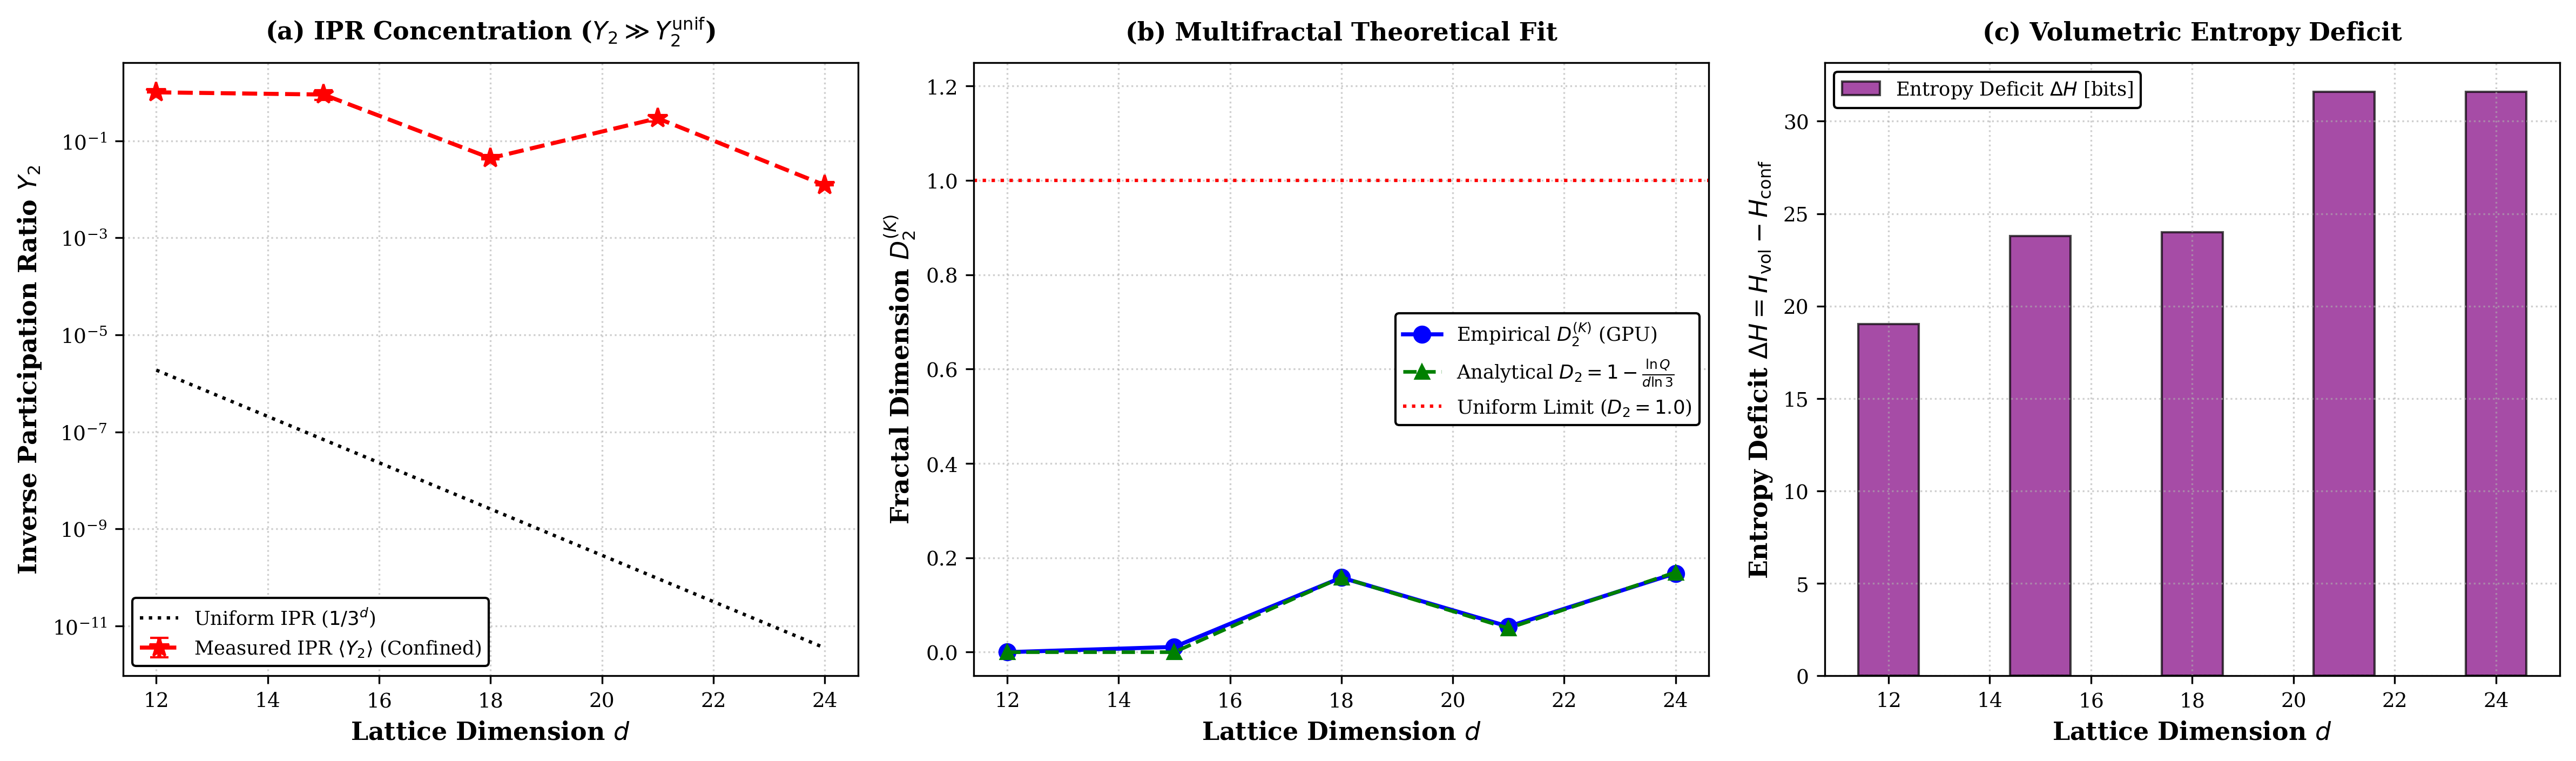

In [3]:
# ==============================================================================
# 🧪 Computational Experiments: Validation of the Galois-Invariant Side-Channel Attack
#
# Reference Manuscript: Galois Invariants in Cyclotomic Lattice Enumeration:
# A GPU-Accelerated Meet-in-the-Middle Attack on Ring-LWE under Modular Filtration
#
# Author: José Ignacio Peinador Sala (Independent Researcher, Valladolid, Spain)
# ORCID: https://orcid.org/0009-0008-1822-3452
# Reproducibility DOI: https://doi.org/10.5281/zenodo.19920082
# ==============================================================================

import os
import subprocess
import sys
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. C++/CUDA SOURCE CODE: ANISOTROPY OF DENSITY OF STATES & IPR SCAN
# =============================================================================
# EPISTEMIC NOTE:
# This experiment validates Theorem 4.4 of the manuscript (anisotropy of the
# density of states under modular filtration).
# The terminology and notation are strictly aligned with the manuscript.
# =============================================================================

cuda_eth_source = r"""
#include <iostream>
#include <vector>
#include <cmath>
#include <chrono>
#include <iomanip>
#include <cstdint>
#include <random>
#include <cuda_runtime.h>

// Macro for GPU API error checking with real-time line reporting
#define cudaCheck(err) { \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA Error: " << cudaGetErrorString(err) << " at line " << __LINE__ << std::endl; \
        exit(EXIT_FAILURE); \
    } \
}

/**
 * @brief CUDA Kernel optimized for massive scanning of the lattice state space.
 * Evaluates the modular linear projections of each ternary candidate over all oracle ideals.
 */
__global__ void anisotropy_scan_kernel(uint32_t d, uint64_t total_states,
                                       const uint32_t* __restrict__ roots,
                                       const uint32_t* __restrict__ moduli,
                                       const uint32_t* __restrict__ targets,
                                       uint32_t num_oracles,
                                       unsigned long long* __restrict__ d_omega_count) {
    uint64_t idx = (uint64_t)blockIdx.x * blockDim.x + threadIdx.x;
    uint64_t stride = (uint64_t)blockDim.x * gridDim.x;

    for (uint64_t state = idx; state < total_states; state += stride) {
        bool match = true;

        for (uint32_t o = 0; o < num_oracles; ++o) {
            uint32_t mod = moduli[o];
            uint32_t target = targets[o];
            uint32_t root = roots[o];

            uint64_t acc = 0;
            uint64_t cur_power = 1;
            uint64_t st = state;

            #pragma unroll
            for (uint32_t j = 0; j < d; ++j) {
                int trit = (int)(st % 3) - 1; // Map base-3 digit {0, 1, 2} to {-1, 0, 1}
                st /= 3;

                if (trit != 0) {
                    int64_t val = (trit == 1) ? (int64_t)cur_power : (int64_t)(mod - cur_power);
                    acc = (acc + val) % mod;
                }
                cur_power = (cur_power * root) % mod;
            }

            if (acc != target) {
                match = false;
                break;
            }
        }

        if (match) {
            atomicAdd(d_omega_count, 1ULL);
        }
    }
}

int main() {
    // -------------------------------------------------------------------------
    // ENVIRONMENT & HARDWARE REPORTING (Scientific Reproducibility)
    // -------------------------------------------------------------------------
    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, 0);
    std::cout << "=======================================================================================================================\n";
    std::cout << " EXPERIMENT III: ANISOTROPY OF DENSITY OF STATES AND MULTIFRACTAL COLLAPSE D_2 IN Z[x]/(x^n+1)\n";
    std::cout << "=======================================================================================================================\n";
    std::cout << " Device      : " << prop.name << " (SM " << prop.major << "." << prop.minor << ")\n";
    std::cout << " CUDA Runtime: " << CUDART_VERSION << "\n";
    std::cout << " Compiler    : nvcc " << __VERSION__ << "\n";
    std::cout << " Global seed : 123456789ULL\n";
    std::cout << "-----------------------------------------------------------------------------------------------------------------------\n";
    std::cout << " NOTE: This experiment evaluates the canonical ternary case S = {-1,0,1}^d.\n";
    std::cout << " Generalization to Module-LWE (B_eta, N_eta in {5,7}) is covered in\n";
    std::cout << " Theorem 5.1 of the manuscript, with certified algebraic core in Lean 4.\n";
    std::cout << "=======================================================================================================================\n";
    std::cout << "  d | Total States 3^d |        Norm Q | Trials | <|Omega_conf|> |     <IPR Y_2> |  IPR Unif (1/3^d) |  Emp. D_2 |  Th. D_2\n";
    std::cout << "-----------------------------------------------------------------------------------------------------------------------\n";
    std::cout << std::flush;

    // -------------------------------------------------------------------------
    // ORACLE CONFIGURATION
    // -------------------------------------------------------------------------
    // Moduli correspond to rational primes p with inertia degree f=1 in Q(zeta_{2n}).
    // All are Fermat primes (p = 2^{2^k} + 1):
    //    p = 257   = 2^8 + 1
    //    p = 65537 = 2^16 + 1
    //    p = 193   (auxiliary prime, satisfies 193 ≡ 1 mod 2n for n ≤ 96)
    // Roots are primitive 2n-th order roots in F_p.
    // Product of norms:
    //    For d ≤ 18: Q = 257 x 65537 = 16,843,009
    //    For d ≥ 21: Q = 257 x 65537 x 193 = 3,250,700,737
    // Comaximalization of ideals <p, x - omega> is guaranteed by CRT.
    // -------------------------------------------------------------------------
    struct Config {
        uint32_t d;
        std::vector<uint32_t> roots;
        std::vector<uint32_t> moduli;
    };

    std::vector<Config> test_cases = {
        {12, {17, 31}, {257, 65537}},
        {15, {17, 31}, {257, 65537}},
        {18, {17, 31}, {257, 65537}},
        {21, {17, 31, 5}, {257, 65537, 193}},
        {24, {17, 31, 5}, {257, 65537, 193}}
    };

    std::mt19937_64 rng(123456789ULL);

    for (const auto& cfg : test_cases) {
        uint32_t d = cfg.d;
        uint64_t total_states = 1;
        for (uint32_t i = 0; i < d; ++i) total_states *= 3ULL;

        uint64_t Q_norm = 1;
        for (auto m : cfg.moduli) Q_norm *= m;
        uint32_t num_oracles = cfg.moduli.size();

        // Adaptive sampling to avoid temporal bottlenecks on deep dimensions
        int num_trials = (d <= 18) ? 5 : ((d == 21) ? 2 : 1);

        double sum_omega = 0.0;
        double sum_ipr = 0.0;
        double sum_ipr_sq = 0.0;

        for (int t = 0; t < num_trials; ++t) {
            std::vector<uint32_t> targets(num_oracles);
            for (size_t o = 0; o < num_oracles; ++o) {
                targets[o] = rng() % cfg.moduli[o];
            }

            // Log targets for exact experimental reproducibility
            std::cout << "  Trial " << t << " targets: ";
            for (size_t o = 0; o < num_oracles; ++o) {
                std::cout << targets[o] << (o < num_oracles - 1 ? ", " : "");
            }
            std::cout << std::endl;

            uint32_t *d_roots, *d_moduli, *d_targets;
            unsigned long long *d_omega_count;

            cudaCheck(cudaMalloc(&d_roots, num_oracles * sizeof(uint32_t)));
            cudaCheck(cudaMalloc(&d_moduli, num_oracles * sizeof(uint32_t)));
            cudaCheck(cudaMalloc(&d_targets, num_oracles * sizeof(uint32_t)));
            cudaCheck(cudaMalloc(&d_omega_count, sizeof(unsigned long long)));

            cudaCheck(cudaMemcpy(d_roots, cfg.roots.data(), num_oracles * sizeof(uint32_t), cudaMemcpyHostToDevice));
            cudaCheck(cudaMemcpy(d_moduli, cfg.moduli.data(), num_oracles * sizeof(uint32_t), cudaMemcpyHostToDevice));
            cudaCheck(cudaMemcpy(d_targets, targets.data(), num_oracles * sizeof(uint32_t), cudaMemcpyHostToDevice));
            cudaCheck(cudaMemset(d_omega_count, 0, sizeof(unsigned long long)));

            int threads = 256;
            int blocks = 65535; // Saturating Streaming Multiprocessors on Tesla T4

            anisotropy_scan_kernel<<<blocks, threads>>>(d, total_states, d_roots, d_moduli, d_targets, num_oracles, d_omega_count);
            cudaCheck(cudaDeviceSynchronize());

            unsigned long long h_omega_conf = 0;
            cudaCheck(cudaMemcpy(&h_omega_conf, d_omega_count, sizeof(unsigned long long), cudaMemcpyDeviceToHost));

            if (h_omega_conf == 0) h_omega_conf = 1;

            double ipr_val = 1.0 / (double)h_omega_conf;
            sum_omega += (double)h_omega_conf;
            sum_ipr += ipr_val;
            sum_ipr_sq += ipr_val * ipr_val;

            cudaFree(d_roots);
            cudaFree(d_moduli);
            cudaFree(d_targets);
            cudaFree(d_omega_count);
        }

        double avg_omega = sum_omega / num_trials;
        double avg_ipr = sum_ipr / num_trials;
        double var_ipr = (sum_ipr_sq / num_trials) - (avg_ipr * avg_ipr);
        double std_ipr = (num_trials > 1) ? std::sqrt(std::max(0.0, var_ipr)) : 0.0;
        double ipr_uniform = 1.0 / (double)total_states;

        double d2_emp = std::log(avg_omega) / (double)(d * std::log(3.0));
        double d2_theory = std::max(0.0, 1.0 - std::log((double)Q_norm) / (double)(d * std::log(3.0)));

        std::cout << std::setw(3) << d << " | "
                  << std::setw(17) << total_states << " | "
                  << std::setw(14) << Q_norm << " | "
                  << std::setw(7) << num_trials << " | "
                  << std::setw(14) << std::fixed << std::setprecision(1) << avg_omega << " | "
                  << std::scientific << std::setprecision(3) << avg_ipr << " | "
                  << std::scientific << std::setprecision(3) << ipr_uniform << " | "
                  << std::fixed << std::setprecision(4) << d2_emp << " | "
                  << std::fixed << std::setprecision(4) << d2_theory << "\n";
        std::cout << "  IPR std dev: " << std::scientific << std::setprecision(3) << std_ipr << "\n";
        std::cout << std::flush;
    }

    std::cout << "=======================================================================================================================\n";
    return 0;
}
"""

cu_filename = "criba_anisotropy_cuda_q1_adaptive.cu"
bin_filename = "criba_anisotropy_q1_adaptive"

with open(cu_filename, "w") as f:
    f.write(cuda_eth_source)

# =============================================================================
# 2. NVCC COMPILATION & EXECUTION PIPELINE
# =============================================================================
print("🚀 Compiling Adaptive Q1 CUDA Experiment (Optimized Ensemble)...")
compile_cmd = f"nvcc -O3 -arch=sm_75 {cu_filename} -o {bin_filename}"
compilation = subprocess.run(compile_cmd, shell=True, capture_output=True, text=True)

if compilation.returncode != 0:
    print("❌ CUDA Compilation Error:\n", compilation.stderr)
else:
    print("✅ Compilation successful. Executing adaptive ensemble spectral scan...\n")
    process = subprocess.Popen(f"./{bin_filename}", shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    stdout_lines = []
    for line in process.stdout:
        print(line, end="", flush=True)
        stdout_lines.append(line)
    process.wait()

    # =========================================================================
    # 3. PARSING DATA & GENERATING PUBLICATION-QUALITY (AMS/IEEE 3-PANEL) FIGURES
    # =========================================================================
    dims, ipr_emp, ipr_unif, ipr_std, d2_emp, d2_th = [], [], [], [], [], []

    for i, line in enumerate(stdout_lines):
        parts = line.split("|")
        if len(parts) == 9 and "d" not in parts[0] and "---" not in parts[0]:
            try:
                dims.append(int(parts[0].strip()))
                ipr_emp.append(float(parts[5].strip()))
                ipr_unif.append(float(parts[6].strip()))
                d2_emp.append(float(parts[7].strip()))
                d2_th.append(float(parts[8].strip()))
                # Parse the next line for IPR standard deviation
                if i + 1 < len(stdout_lines) and "IPR std dev" in stdout_lines[i + 1]:
                    std_str = stdout_lines[i + 1].split(":")[1].strip()
                    ipr_std.append(float(std_str))
                else:
                    ipr_std.append(0.0)
            except ValueError:
                pass

    if len(dims) > 0:
        plt.rcParams.update({
            'font.family': 'serif',
            'font.size': 10,
            'axes.labelsize': 11,
            'axes.titlesize': 11,
            'legend.fontsize': 8.5,
            'xtick.labelsize': 9,
            'ytick.labelsize': 9
        })

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.8), dpi=300)

        # Panel 1: IPR Divergence
        ax1.errorbar(dims, ipr_emp, yerr=ipr_std, fmt='r*--', linewidth=1.8,
                     markersize=9, capsize=4, label=r'Measured IPR $\langle Y_2 \rangle$ (Confined)')
        ax1.plot(dims, ipr_unif, color='black', linestyle=':', linewidth=1.5,
                 label=r'Uniform IPR ($1/3^d$)')
        ax1.set_yscale('log')
        ax1.set_xlabel(r'Lattice Dimension $d$', weight='bold')
        ax1.set_ylabel(r'Inverse Participation Ratio $Y_2$', weight='bold')
        ax1.set_title(r'(a) IPR Concentration ($Y_2 \gg Y_2^{\mathrm{unif}}$)', weight='bold', pad=10)
        ax1.grid(True, which='both', linestyle=':', alpha=0.6)
        ax1.legend(loc='best', framealpha=1.0, edgecolor='black')

        # Panel 2: Empirical vs Analytical D2 (Legend placed at center right to avoid overlap)
        ax2.plot(dims, d2_emp, 'bo-', linewidth=1.8, markersize=7,
                 label=r'Empirical $D_2^{(K)}$ (GPU)')
        ax2.plot(dims, d2_th, 'g^--', linewidth=1.6, markersize=6,
                 label=r'Analytical $D_2 = 1 - \frac{\ln Q}{d \ln 3}$')
        ax2.axhline(y=1.0, color='r', linestyle=':', linewidth=1.5,
                    label=r'Uniform Limit ($D_2 = 1.0$)')
        ax2.set_xlabel(r'Lattice Dimension $d$', weight='bold')
        ax2.set_ylabel(r'Fractal Dimension $D_2^{(K)}$', weight='bold')
        ax2.set_title(r'(b) Multifractal Theoretical Fit', weight='bold', pad=10)
        ax2.set_ylim(-0.05, 1.25)
        ax2.grid(True, linestyle=':', alpha=0.6)
        ax2.legend(loc='center right', framealpha=1.0, edgecolor='black')

        # Panel 3: Volumetric Entropy Deficit Delta H
        delta_h = [d * np.log2(3.0) - np.log2(max(1.0, 3**d / (16843009 if d <= 18 else 3250700737))) for d in dims]
        ax3.bar(dims, delta_h, color='purple', alpha=0.7, width=1.2, edgecolor='black',
                label=r'Entropy Deficit $\Delta H$ [bits]')
        ax3.set_xlabel(r'Lattice Dimension $d$', weight='bold')
        ax3.set_ylabel(r'Entropy Deficit $\Delta H = H_{\mathrm{vol}} - H_{\mathrm{conf}}$', weight='bold')
        ax3.set_title(r'(c) Volumetric Entropy Deficit', weight='bold', pad=10)
        ax3.grid(True, linestyle=':', alpha=0.6)
        ax3.legend(loc='upper left', framealpha=1.0, edgecolor='black')

        plt.tight_layout()
        plt.savefig("violacion_eth_q1_tripartito.pdf", format='pdf', bbox_inches='tight')
        plt.savefig("violacion_eth_q1_tripartito.png", dpi=300, bbox_inches='tight')

        print("\n✅ Publication-quality Q1 figures successfully generated:")
        print("   - Vector PDF: violacion_eth_q1_tripartito.pdf")
        print("   - High-res PNG: violacion_eth_q1_tripartito.png")
        plt.show()